##Phase 1: Data Collection & Understanding


In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the retail sales dataset
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore.csv


In [ ]:
df = pd.read_csv("SampleSuperstore.csv", encoding='latin1')

In [ ]:
# Displaying first 5 rows of dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Checking number of rows and columns in dataset
df.shape

(9994, 21)

In [ ]:
# Checking all columns in datset
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
# Understanding dataset structure and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
# Generating statistical summary of numerical columns
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


##Phase 2: Data Cleaning & Preparation

In [ ]:
# Checking for missing values in dataset
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Checking duplicate records in dataset
df.duplicated().sum()

np.int64(0)

In [ ]:
# Standardizing column names for better readability
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('-', '_')
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [ ]:
# Converting date columns into datetime format
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [ ]:
# Creating additional columns for time-based analysis
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

# Calculating profit margin percentage
df['profit_margin'] = (df['profit'] / df['sales']) * 100

In [ ]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,order_year,order_month,month_name,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,11.25


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub_category   9994 n

##PHASE 3 — EXPLORATORY DATA ANALYSIS (EDA)

###SECTION 1 — SALES ANALYSIS

1. Monthly Sales Trend


In [ ]:
# Analysing monthly sales trend
monthly_sales = df.groupby('order_month')['sales'].sum().reset_index()

monthly_sales

,order_month,sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


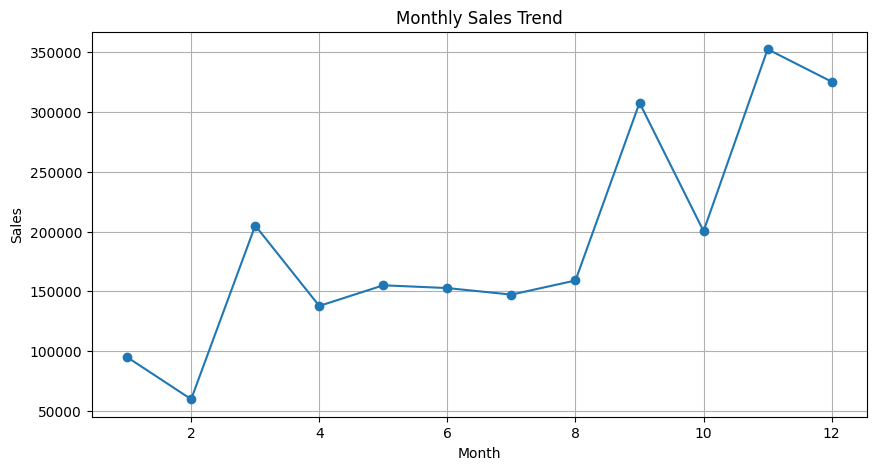

In [ ]:
# Visualization
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['order_month'],
         monthly_sales['sales'],
         marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.grid(True)

plt.show()

Insights:
- Sales fluctuate across different months.
- Some months show significantly higher sales indicating seasonal demand.
- Business experiences peak sales during festive or high-demand periods.

2. Top-Selling Products

In [ ]:
# Identifying top-selling products based on sales revenue
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

top_products

,sales
product_name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


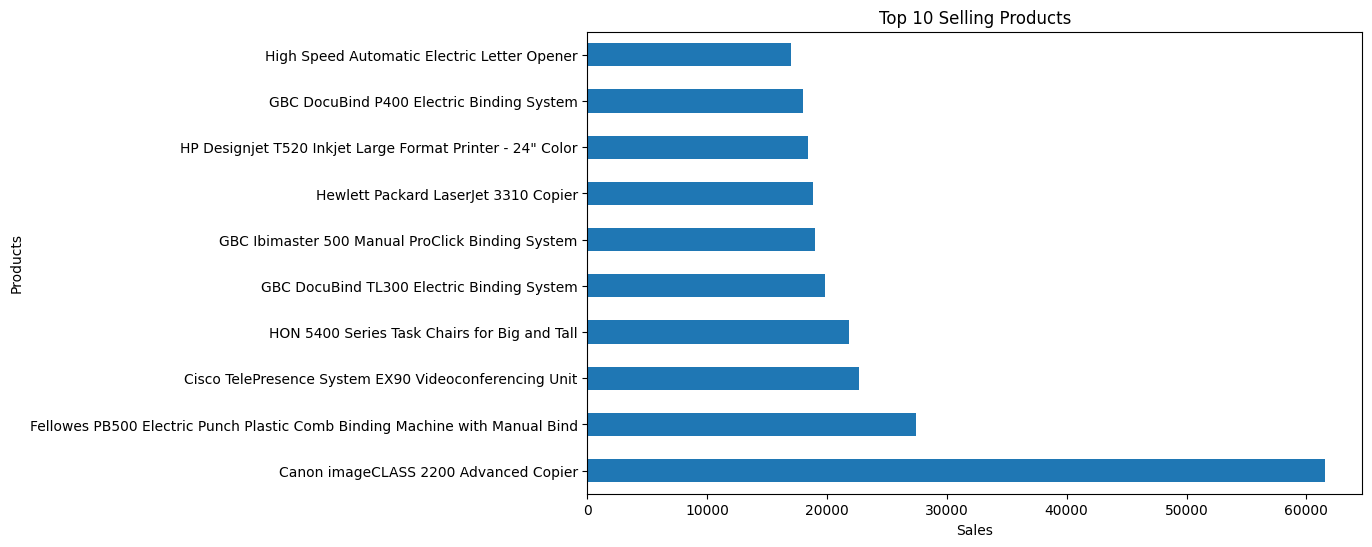

In [ ]:
#Visualization
top_products.plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Selling Products')
plt.xlabel('Sales')
plt.ylabel('Products')

plt.show()

Insights:
- A few products contribute major portion of total revenue.
- High-performing products should be promoted more aggressively.
- Inventory of best-selling products should be maintained properly.

3. Region-wise Revenue

In [ ]:
# Analysing revenue generated across different regions
region_sales = df.groupby('region')['sales'].sum()

region_sales

,sales
region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


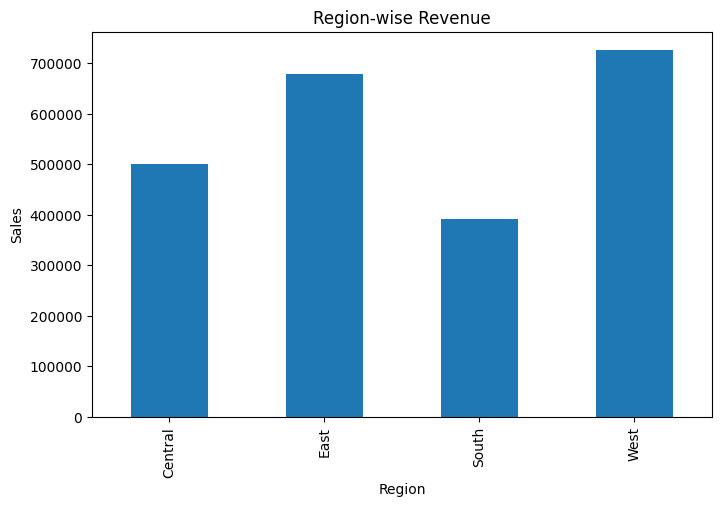

In [ ]:
#Visualization
region_sales.plot(kind='bar', figsize=(8,5))

plt.title('Region-wise Revenue')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

Insights:
- Certain regions contribute higher sales compared to others.
- Low-performing regions may require additional marketing strategies.
- Regional analysis helps management allocate resources effectively.

4. Profit Margin Analysis


In [ ]:
# Analysing average profit margin by category
avg_profit_margin = df.groupby('category')['profit_margin'].mean()

avg_profit_margin

,profit_margin
category,
Furniture,3.878353
Office Supplies,13.803029
Technology,15.613805


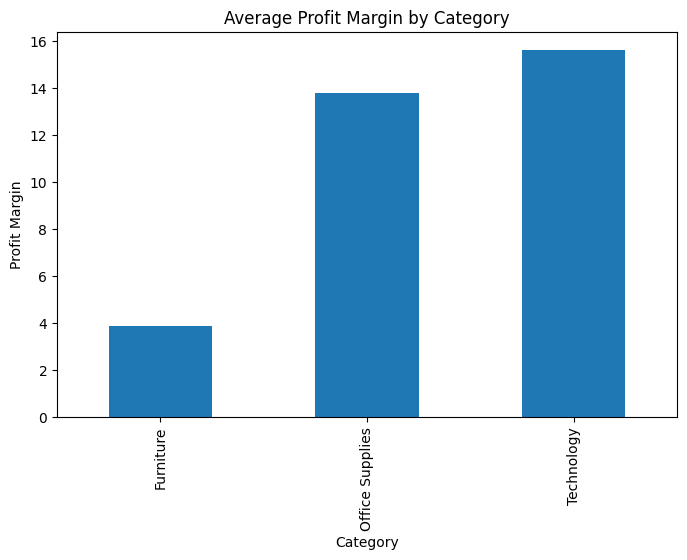

In [ ]:
#Visualization
avg_profit_margin.plot(kind='bar', figsize=(8,5))

plt.title('Average Profit Margin by Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin')

plt.show()

Insights:
- Some product categories generate higher profit margins.
- Categories with low or negative margins need pricing review.
- Profitability analysis helps improve business decisions.

###SECTION 2 — CUSTOMER ANALYSIS
5. New vs Repeat Customers


In [ ]:
# Comparing new customers and repeat customers
customer_orders = df.groupby('customer_id')['order_id'].count()

In [ ]:
#Separate New & Repeat Customers
new_customers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()

print("New Customers:", new_customers)
print("Repeat Customers:", repeat_customers)

New Customers: 5
Repeat Customers: 788


Insights:
- Repeat customers indicate customer satisfaction and loyalty.
- High number of one-time customers may indicate churn risk.
- Business should focus on customer retention strategies.

6. Customer Segmentation


In [ ]:
# Analysing sales contribution from different customer segments
segment_sales = df.groupby('segment')['sales'].sum()

segment_sales

,sales
segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


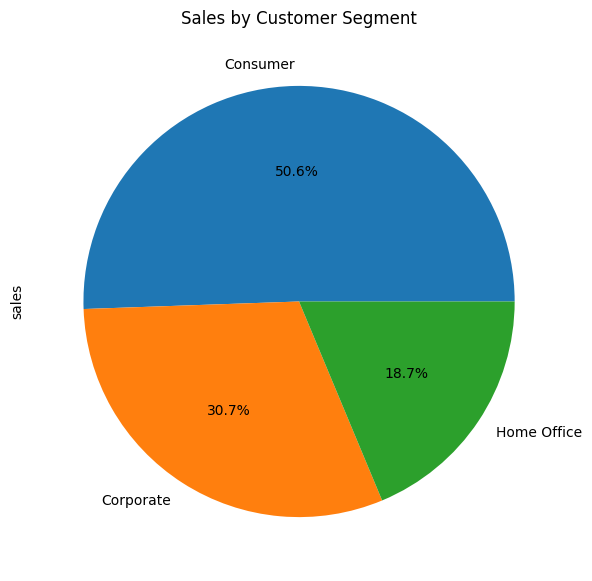

In [ ]:
#Visualization
segment_sales.plot(kind='pie',
                   autopct='%1.1f%%',
                   figsize=(7,7))

plt.title('Sales by Customer Segment')

plt.show()

Insights:
- Consumer segment contributes significant sales revenue.
- Different customer segments show different purchasing behavior.
- Marketing campaigns can be customized for each segment.

7. High-Value Customers


In [ ]:
# Identifying customers contributing highest revenue
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

top_customers

,sales
customer_name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


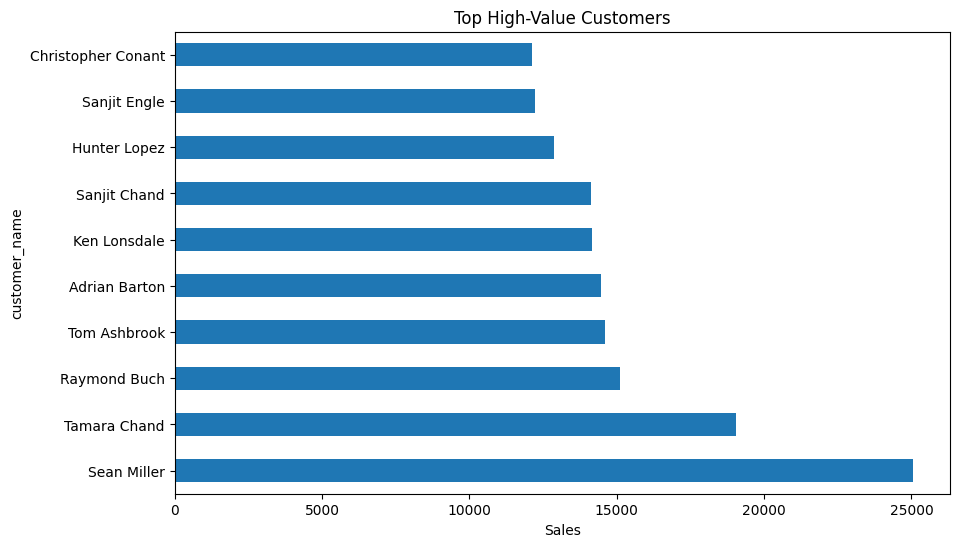

In [ ]:
#Visualization
top_customers.plot(kind='barh', figsize=(10,6))

plt.title('Top High-Value Customers')
plt.xlabel('Sales')

plt.show()

Insights:
- High-value customers contribute major business revenue.
- These customers should receive loyalty benefits and premium support.
- Retaining high-value customers is essential for business growth.

8. Churn Probability Indicators

In [ ]:
# Identifying customers with possible churn risk
churn_risk = customer_orders[customer_orders == 1]

print("Customers at Churn Risk:", len(churn_risk))

Customers at Churn Risk: 5


Insights:
- Customers with only one purchase may stop buying in future.
- Retention campaigns can help reduce churn rate.
- Personalized offers may improve repeat purchases.

###SECTION 3 — PRODUCT ANALYSIS
9. Fast-Moving Products

In [ ]:
# Identifying products sold in highest quantity
fast_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

fast_products

,quantity
product_name,
Staples,215
Staple envelope,170
Easy-staple paper,150
Staples in misc. colors,86
KI Adjustable-Height Table,74
Storex Dura Pro Binders,71
Avery Non-Stick Binders,71
GBC Premium Transparent Covers with Diagonal Lined Pattern,67
"Situations Contoured Folding Chairs, 4/Set",64


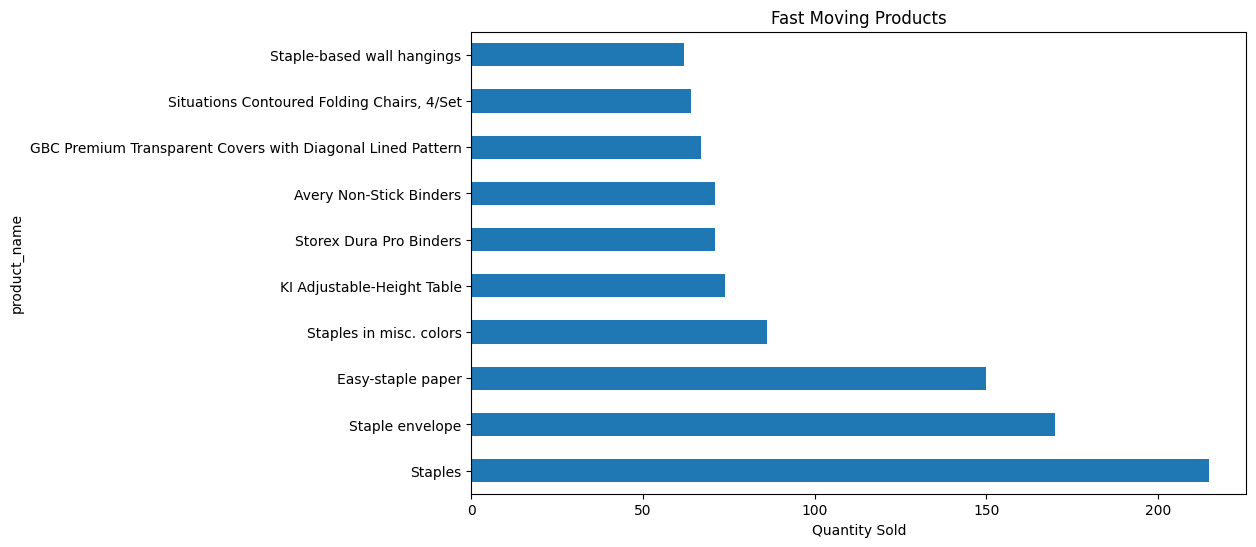

In [ ]:
#Visualization
fast_products.plot(kind='barh', figsize=(10,6))

plt.title('Fast Moving Products')
plt.xlabel('Quantity Sold')

plt.show()

Insights:
- Fast-moving products have consistently high demand.
- Business should maintain sufficient inventory for these products.
- These products can be prioritized in promotions and advertisements.

10. Dead Stock Items

In [ ]:
# Identifying products with very low sales
dead_stock = df.groupby('product_name')['sales'].sum().sort_values().head(10)

dead_stock

,sales
product_name,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624
Avery 5,5.760
Xerox 20,6.480
Grip Seal Envelopes,7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800
Xerox 1989,7.968
4009 Highlighters,8.040
Stockwell Gold Paper Clips,8.096


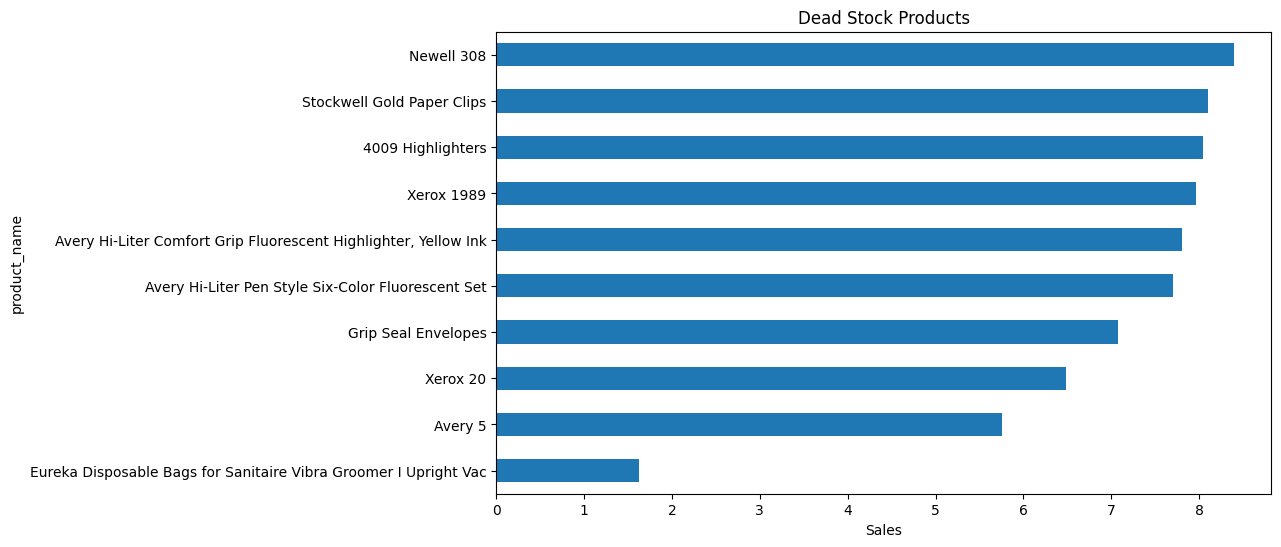

In [ ]:
#Visualization
dead_stock.plot(kind='barh', figsize=(10,6))

plt.title('Dead Stock Products')
plt.xlabel('Sales')

plt.show()

Insights:
- Dead stock products contribute very little revenue.
- Excess inventory of these products increases storage cost.
- Business may consider discounts or discontinuation of such products.

11. High Return Categories

In [ ]:
# Analysing categories generating losses
loss_category = df[df['profit'] < 0]

high_loss_categories = loss_category.groupby('category')['profit'].sum()

high_loss_categories

,profit
category,
Furniture,-60936.1090
Office Supplies,-56615.2585
Technology,-38579.9182


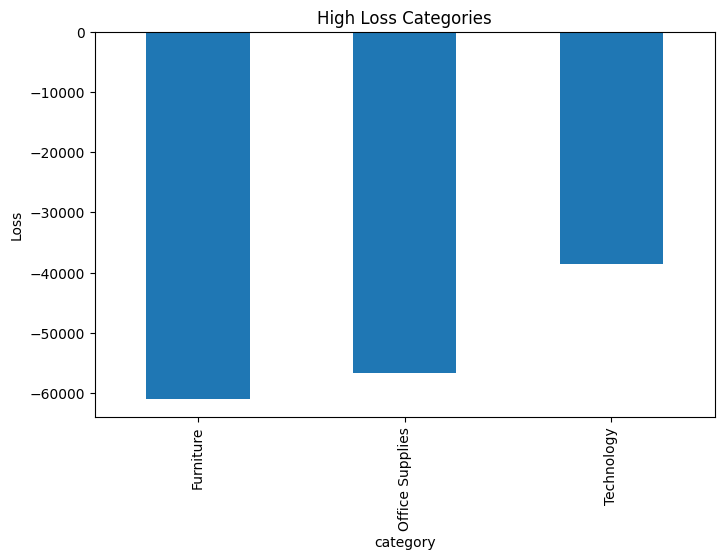

In [ ]:
#Visualization
high_loss_categories.plot(kind='bar', figsize=(8,5))

plt.title('High Loss Categories')
plt.ylabel('Loss')

plt.show()

Insights:
- Some categories are generating negative profits.
- High discounts may be reducing profitability.
- Pricing and discount strategies should be reviewed carefully.

In [ ]:
df.to_csv("cleaned_superstore_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_superstore_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final Recommendations:
- Increase focus on high-performing regions and products.
- Improve retention strategies for repeat customers.
- Reduce excessive discounts on low-profit categories.
- Maintain stock for fast-moving products.
- Introduce targeted marketing campaigns for low-performing regions.
- Provide loyalty programs for high-value customers.

##Phase 5 — Sales Forecasting using Linear Regression
1. IMPORT REQUIRED LIBRARIES


In [ ]:
# Importing libraries for machine learning and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

2. CREATE MONTHLY SALES DATASET

In [ ]:
# Creating monthly sales dataset

monthly_data = df.groupby('order_month')['sales'].sum().reset_index()

monthly_data

,order_month,sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


3. DEFINE FEATURES & TARGET

In [ ]:
# Defining input and target variables

X = monthly_data[['order_month']]

y = monthly_data['sales']

In [ ]:
print(X.head())
print(y.head())

   order_month
0            1
1            2
2            3
3            4
4            5
0     94924.8356
1     59751.2514
2    205005.4888
3    137762.1286
4    155028.8117
Name: sales, dtype: float64


4. CREATE & TRAIN MODEL

In [ ]:
# Creating and training Linear Regression model

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [ ]:
print("Model training completed successfully")

Model training completed successfully


5. PREDICT SALES

In [ ]:
# Predicting sales using trained model

predictions = model.predict(X)

predictions

array([ 76208.97326154,  97158.8699458 , 118108.76663007, 139058.66331434,
       160008.5599986 , 180958.45668287, 201908.35336713, 222858.2500514 ,
       243808.14673566, 264758.04341993, 285707.9401042 , 306657.83678846])

6. EVALUATE MODEL PERFORMANCE

In [ ]:
# Evaluating model performance

r2 = r2_score(y, predictions)

print("R2 Score:", r2)

R2 Score: 0.6750168870279232


7. PLOT ACTUAL VS PREDICTED SALES

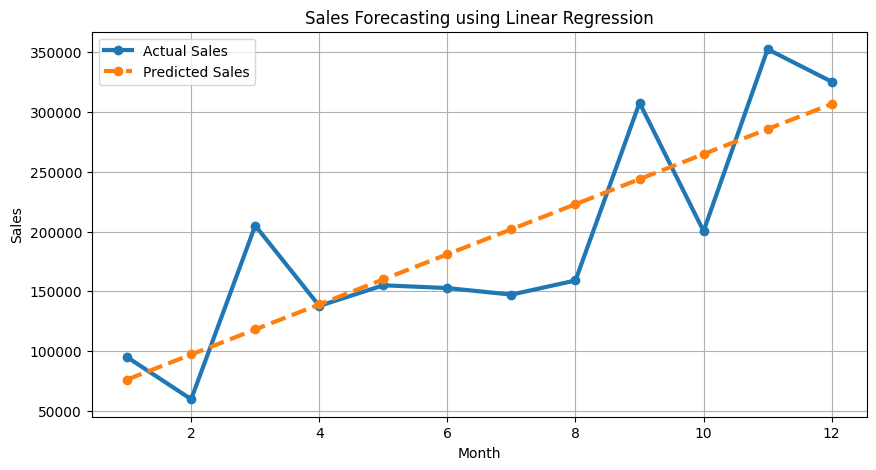

In [ ]:
# Visualizing actual vs predicted sales

plt.figure(figsize=(10,5))

# Actual Sales
plt.plot(monthly_data['order_month'],
         y,
         marker='o',
         linewidth=3,
         label='Actual Sales')

# Predicted Sales
plt.plot(monthly_data['order_month'],
         predictions,
         marker='o',
         linestyle='--',
         linewidth=3,
         label='Predicted Sales')

# Titles and labels
plt.title('Sales Forecasting using Linear Regression')

plt.xlabel('Month')

plt.ylabel('Sales')

# Showing legend
plt.legend()

# Grid
plt.grid(True)

# Display chart
plt.show()

Insights:

• The forecasting model predicts future sales trends based on historical monthly sales data.

• Sales show increasing trend during high-demand months.

• The predicted trend closely follows actual sales patterns.

• Predictive analytics can help businesses improve inventory and sales planning.